# Dự Báo Nhu Cầu Tiêu Thụ Điện Năng (Energy Consumption Forecasting)

Dự án này sử dụng mô hình **Long Short-Term Memory (LSTM)** để dự báo lượng điện tiêu thụ hàng giờ dựa trên dữ liệu lịch sử từ tập dữ liệu PJM Interconnection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

print("Libraries loaded successfully.")

/Users/tranbaonguyen/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries loaded successfully.


## 1. Tải và Khám Phá Dữ Liệu

Chúng ta sẽ sử dụng dữ liệu `PJME_hourly.csv` để huấn luyện mô hình.

                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


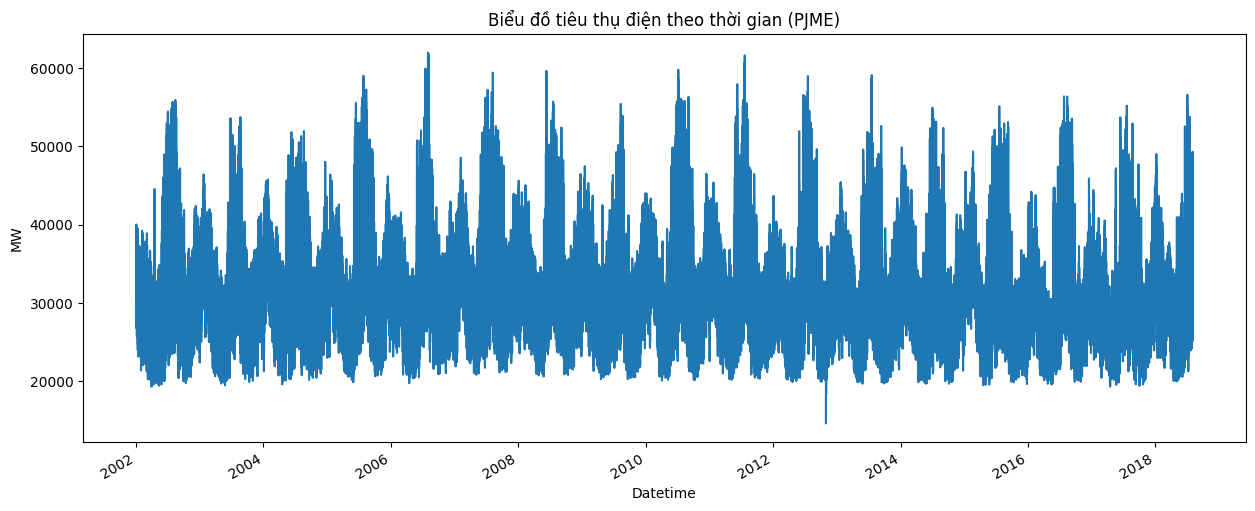

In [2]:
df = pd.read_csv('dataset/PJME_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()

print(df.head())

plt.figure(figsize=(15, 6))
df['PJME_MW'].plot()
plt.title('Biểu đồ tiêu thụ điện theo thời gian (PJME)')
plt.ylabel('MW')
plt.show()

## 2. Phân Tích Chu Kỳ (Seasonality Analysis)

Kiểm tra sự thay đổi của lượng điện tiêu thụ theo giờ trong ngày, ngày trong tuần và tháng trong năm.

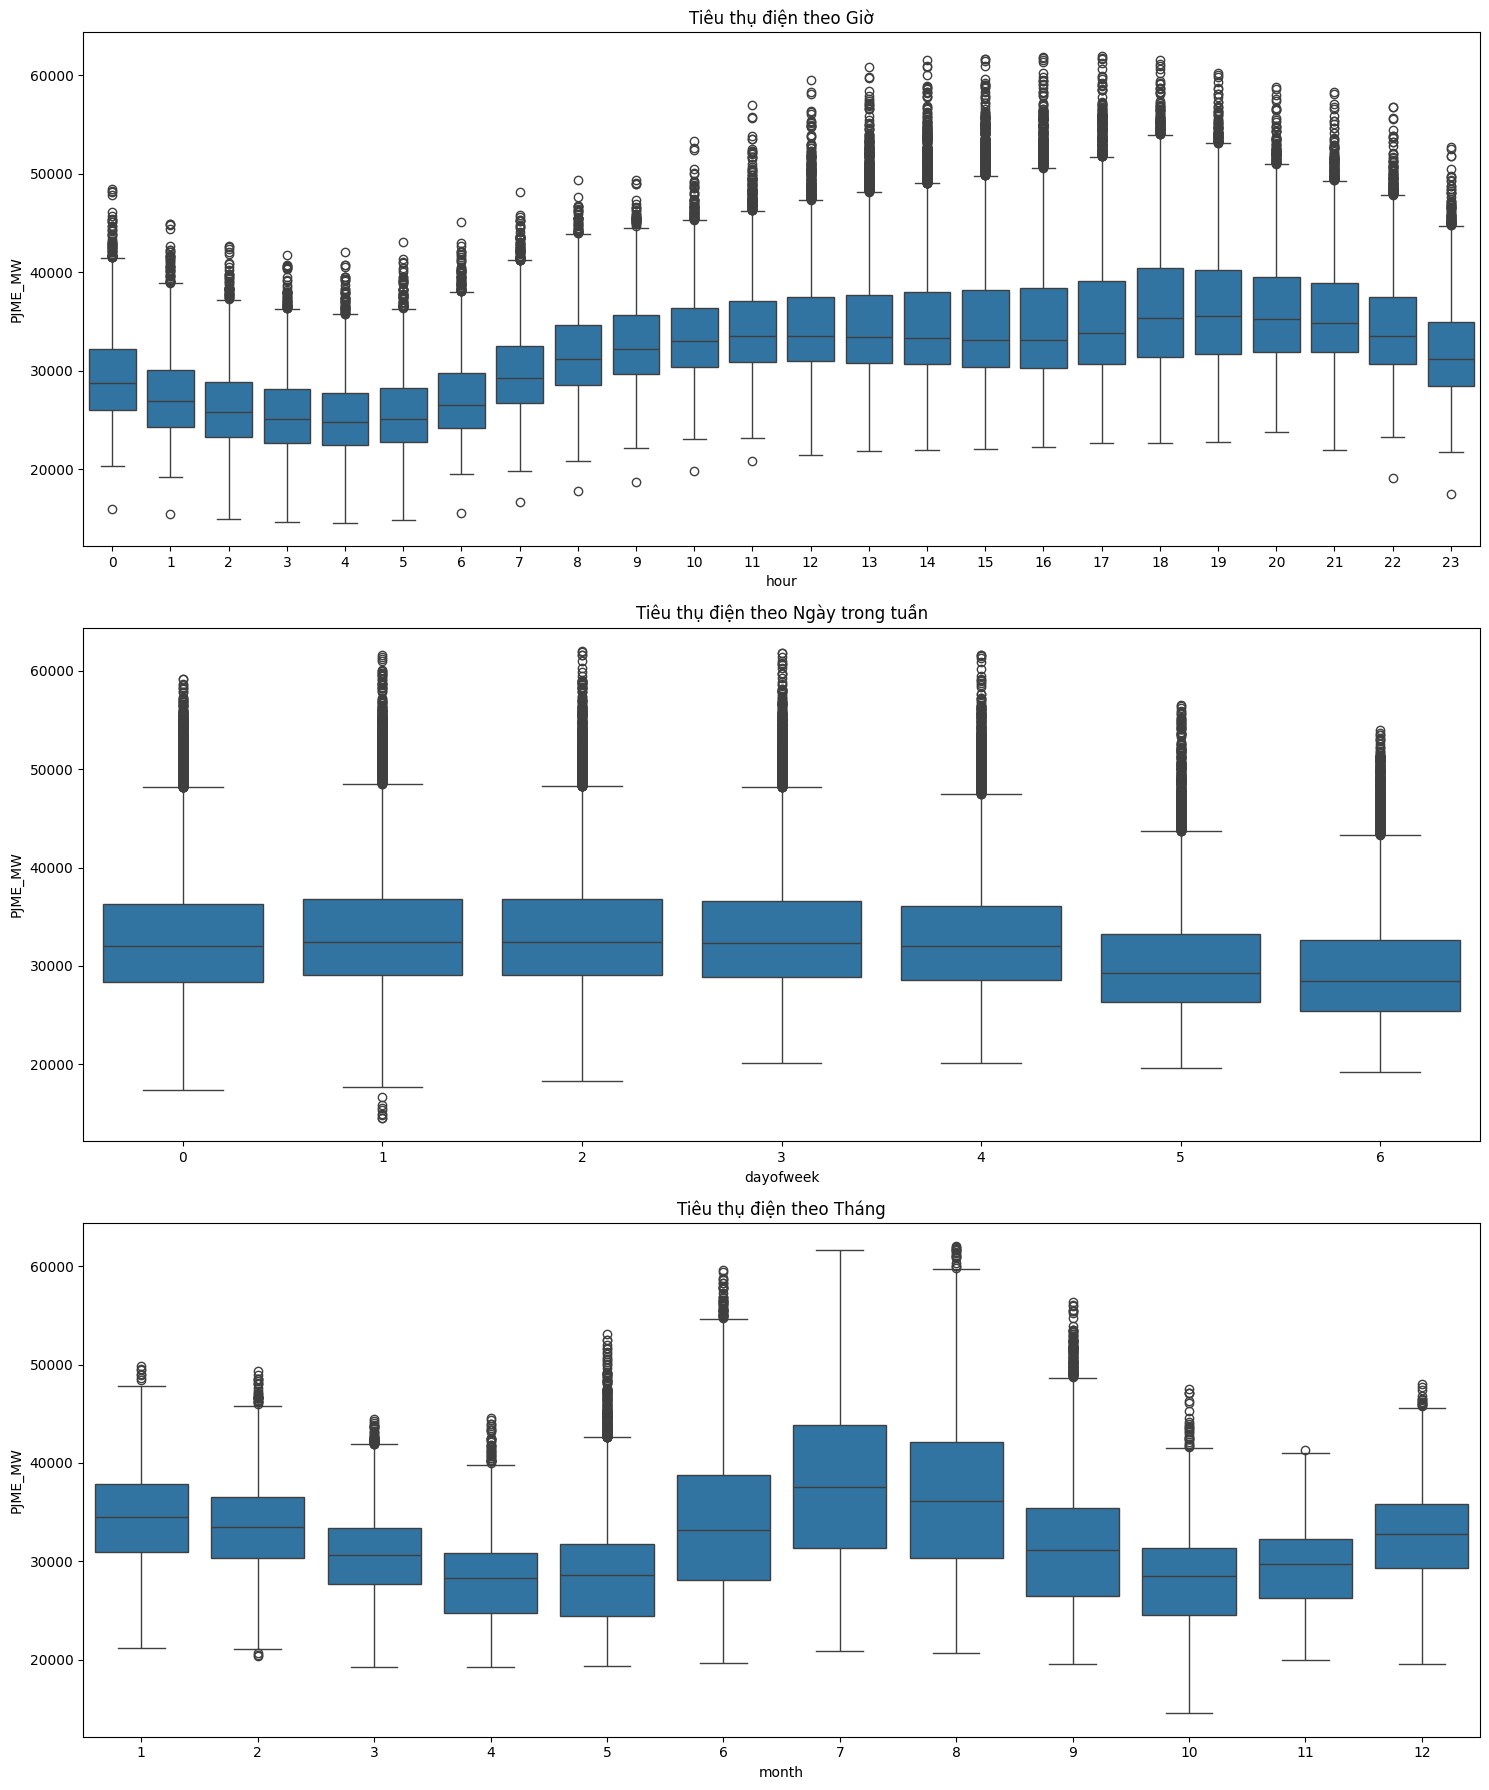

In [3]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

fig, axes = plt.subplots(3, 1, figsize=(15, 18))
sns.boxplot(data=df, x='hour', y='PJME_MW', ax=axes[0])
axes[0].set_title('Tiêu thụ điện theo Giờ')

sns.boxplot(data=df, x='dayofweek', y='PJME_MW', ax=axes[1])
axes[1].set_title('Tiêu thụ điện theo Ngày trong tuần')

sns.boxplot(data=df, x='month', y='PJME_MW', ax=axes[2])
axes[2].set_title('Tiêu thụ điện theo Tháng')

plt.tight_layout()
plt.show()

## 3. Tiền Xử Lý Dữ Liệu (Preprocessing)

Chuẩn hóa dữ liệu về khoảng [0, 1] và tạo các chuỗi thời gian (sequences) với độ dài 24 giờ.

In [4]:
data = df[['PJME_MW']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 24
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

X_train, y_train = create_sequences(train_data, SEQ_LENGTH)
X_test, y_test = create_sequences(test_data, SEQ_LENGTH)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (116268, 24, 1)
X_test shape: (29050, 24, 1)


## 4. Xây Dựng và Huấn Luyện Mô Hình LSTM

In [5]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

print("Bắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Bắt đầu huấn luyện...
Epoch 1/10


/Users/tranbaonguyen/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1636/1636 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0072 - val_loss: 4.9507e-04
Epoch 2/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 7.4990e-04 - val_loss: 2.7037e-04
Epoch 3/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 5.0726e-04 - val_loss: 1.9222e-04
Epoch 4/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 4.1735e-04 - val_loss: 2.2435e-04
Epoch 5/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 3.7387e-04 - val_loss: 1.6740e-04
Epoch 6/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 3.5099e-04 - val_loss: 4.1033e-04
Epoch 7/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 3.5861e-04 - val_loss: 1.7481e-04
Epoch 8/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 3.2798e-04 - val_loss: 4.3255e-04
Epoch 9/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 3.2797e-04 - val_loss: 1.9842e-04
Epoch 10/10
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 3.0425e-04 - val_loss: 1.6367e-04


## 5. Đánh Giá và Dự Báo

908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
RMSE: 589.51
MAE: 481.48


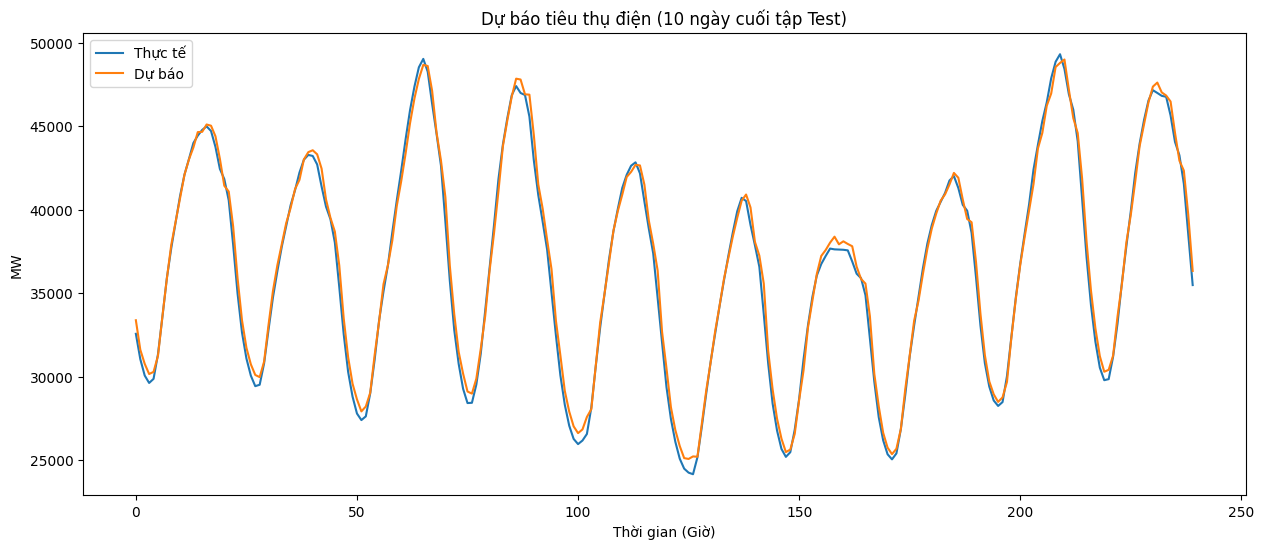

In [6]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))
mae = mean_absolute_error(y_test_unscaled, predictions)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(15, 6))
plt.plot(y_test_unscaled[-240:], label='Thực tế')
plt.plot(predictions[-240:], label='Dự báo')
plt.title('Dự báo tiêu thụ điện (10 ngày cuối tập Test)')
plt.xlabel('Thời gian (Giờ)')
plt.ylabel('MW')
plt.legend()
plt.show()

## 6. Lưu Mô Hình

In [7]:
model.save('pjme_lstm_model.h5')
print("Đã lưu mô hình pjme_lstm_model.h5")

Đã lưu mô hình pjme_lstm_model.h5
